<a href="https://colab.research.google.com/github/abu-9/data_preparation_project/blob/IJC-319---CNC-Milling-Analysis/CNC_Milling_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Define the valid cutting stages to retain from the machining process column
cutting_stages = [
    "Layer 1 Up",
    "Layer 1 Down",
    "Layer 2 Up",
    "Layer 2 Down",
    "Layer 3 Up",
    "Layer 3 Down"
]

def clean_experiment(file_name, tool_condition, group_id, feedrate, pressure):
  """
  Loads and cleans a single CNC experiment CSV file.

  Parameters:
    file_name = path to the raw CSV file
    tool_condition = 'worn' or 'unworn' tool label
    group_id = experiment group number for grouping paired comparisons
    feedrate = cutting feedrate used in the experiment
    pressure = clamp pressure used in the experiment

  Returns:
    A cleaned DataFrame with relevant columns and metadata labels.

  """

    # Load the raw experiment data from CSV
    df = pd.read_csv(file_name)

    # Retain only the current feedback sensor reading and the machining process stage
    df = df[["S1_CurrentFeedback","Machining_Process"]]

    # Filter to include only active cutting stages
    df = df[df["Machining_Process"].isin(cutting_stages)]

    # reset index after filtering to ensure clean sequential indexing
    df = df.reset_index(drop=True)

    # Add metadata columns to identify the experiment conditions
    df["tool_condition"] = tool_condition
    df["group"] = group_id
    df["feedrate"] = feedrate
    df["clamp_pressure"] = pressure

    return df

In [ ]:
# Initialise an empty list to collect cleaned DataFrames from each experiment
datasets = []

# Group 1 - Feedrate: 3, Clamp Pressure: 2.5
datasets.append(clean_experiment("experiment_17.csv","unworn",1,3,2.5))
datasets.append(clean_experiment("experiment_18.csv","worn",1,3,2.5))

# Group 2 - Feedrate: 3, Clamp Pressure: 3
datasets.append(clean_experiment("experiment_12.csv","unworn",2,3,3))
datasets.append(clean_experiment("experiment_14.csv","worn",2,3,3))

# Group 3 - Feedrate: 3, Clamp Pressure: 4
datasets.append(clean_experiment("experiment_11.csv","unworn",3,3,4))
datasets.append(clean_experiment("experiment_13.csv","worn",3,3,4))

# Group 4 - Feedrate: 6, Clamp Pressure: 3
datasets.append(clean_experiment("experiment_03.csv","unworn",4,6,3))
datasets.append(clean_experiment("experiment_15.csv","worn",4,6,3))

# Group 5 - Feedrate: 6, Clamp Pressure: 4
datasets.append(clean_experiment("experiment_01.csv","unworn",5,6,4))
datasets.append(clean_experiment("experiment_06.csv","worn",5,6,4))

# Group 6 - Feedrate: 20, Clamp Pressure: 4
datasets.append(clean_experiment("experiment_02.csv","unworn",6,20,4))
datasets.append(clean_experiment("experiment_08.csv","worn",6,20,4))

In [ ]:
# Concatenate all cleaned experiment DataFrames into a single unified dataset
final_dataset = pd.concat(datasets, ignore_index=True)

# Export the final cleaned dataset to CSV for use in analysis
final_dataset.to_csv("cleaned_cnc_dataset.csv", index=False)

**Data Cleaning**

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the cleaned CNC dataset produced during preprocessing
df = pd.read_csv("cleaned_cnc_dataset.csv")

# Preview the first few rows to confirm the data loaded correctly
df.head()

,S1_CurrentFeedback,Machining_Process,tool_condition,group,feedrate,clamp_pressure
0,17.6,Layer 1 Up,unworn,1,3,2.5
1,17.6,Layer 1 Up,unworn,1,3,2.5
2,17.1,Layer 1 Up,unworn,1,3,2.5
3,19.3,Layer 1 Up,unworn,1,3,2.5
4,20.8,Layer 1 Up,unworn,1,3,2.5


In [3]:
# Check for missing values in each column — any nulls may affect feature extraction
df.isnull().sum()

,0
S1_CurrentFeedback,0
Machining_Process,0
tool_condition,0
group,0
feedrate,0
clamp_pressure,0


In [4]:
# Check for fully duplicate rows — duplicates could distort statistical features
df.duplicated().sum()

np.int64(7151)

In [5]:
# ── GLOBAL FEATURE EXTRACTION ────────────────────────────────────────────────
# Compute summary statistics for each group/tool_condition pair across the
# entire signal, providing a high-level view of current behaviour per experiment

global_features = []

for (group, tool), gdf in df.groupby(["group","tool_condition"]):

    signal = gdf["S1_CurrentFeedback"]

    global_features.append({
        "group": group,
        "tool_condition": tool,
        "mean_current": signal.mean(),                        # Average current draw
        "std_current": signal.std(),                          # Variability around the mean
        "variance_current": signal.var(),                     # Spread of the signal
        "rms_current": np.sqrt((signal**2).mean()),           # Energy-sensitive average
        "max_current": signal.max(),                          # Peak current observed
        "min_current": signal.min()                           # Lowest current observed
    })

# Convert list of feature dictionaries into a structured DataFrame
global_feature_df = pd.DataFrame(global_features)

global_feature_df

,group,tool_condition,mean_current,std_current,variance_current,rms_current,max_current,min_current
0,1,unworn,18.255574,6.821127,46.527769,19.487399,30.3,-7.46
1,1,worn,17.763091,8.021511,64.344639,19.489331,67.9,-3.94
2,2,unworn,19.136788,7.315629,53.518422,20.486574,69.3,-3.30
3,2,worn,17.774134,8.339120,69.540924,19.632194,67.8,-4.93
4,3,unworn,18.284711,8.388379,70.364907,20.115959,70.8,-2.22
5,3,worn,17.857510,8.402226,70.597403,19.734310,68.4,-1.62
6,4,unworn,14.835044,10.664025,113.721434,18.267290,74.0,-1.25
7,4,worn,14.819419,9.690996,93.915395,17.703346,29.9,-4.54
8,5,unworn,21.115812,4.135020,17.098389,21.516474,62.0,9.37
9,5,worn,17.518995,8.487495,72.037565,19.464923,63.1,-5.10


In [18]:
# ── WINDOWED FEATURE EXTRACTION ──────────────────────────────────────────────
# Sliding window segmentation captures local signal behaviour over time,
# which is more sensitive to gradual tool wear than global statistics alone

window_size = 50          # Number of data points per window segment
step_size = 25            # Step between windows - 50% overlap to avoid missing transitions

segments = []

# --- 1. WINDOW CREATION ---
for (group, process, tool), gdf in df.groupby(["group", "Machining_Process", "tool_condition"]):

    # Extract raw signal values as a NumPy array for efficient windowed slicing
    signal = gdf["S1_CurrentFeedback"].values

    # Slide the window across the signal, stopping when a full window no longer fits
    for i in range(0, len(signal)-window_size+1, step_size):
        window = signal[i:i+window_size]

        # Compute the same statistical features as global extraction, but per window
        segments.append({
            "group": group,
            "process": process,
            "tool_condition": tool,
            "mean_current": np.mean(window),
            "std_current": np.std(window),
            "variance_current": np.var(window),
            "rms_current": np.sqrt(np.mean(window**2)),
            "max_current": np.max(window),
            "min_current": np.min(window)
        })

# Convert all window segments into a structured DataFrame for analysis
window_df = pd.DataFrame(segments)

**Analysis: Research Question 1**

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, levene

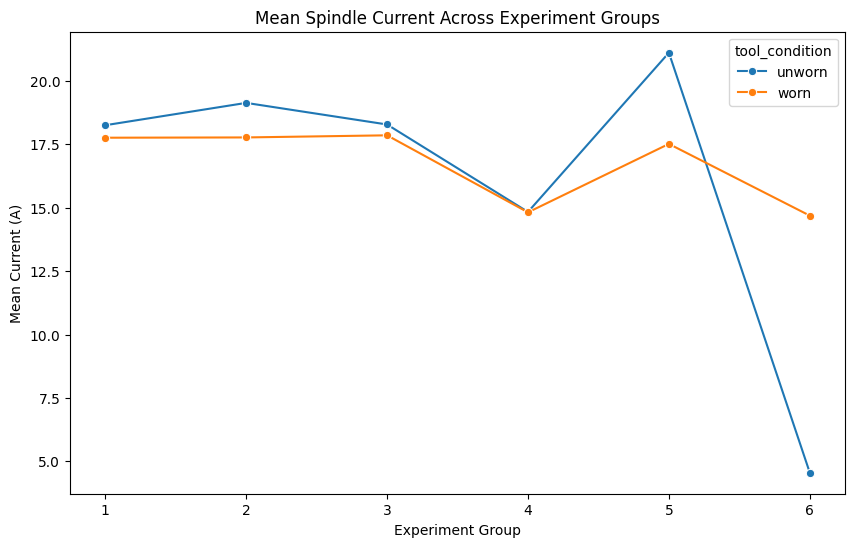

In [8]:
# Create a line plot graph showing how mean spindle current varies across experimental groups.
plt.figure(figsize=(10,6))

sns.lineplot(
    data=global_feature_df,
    x="group",
    y="mean_current",
    hue="tool_condition",
    marker="o"
)

plt.title("Mean Spindle Current Across Experiment Groups")
plt.xlabel("Experiment Group")
plt.ylabel("Mean Current (A)")

plt.show()

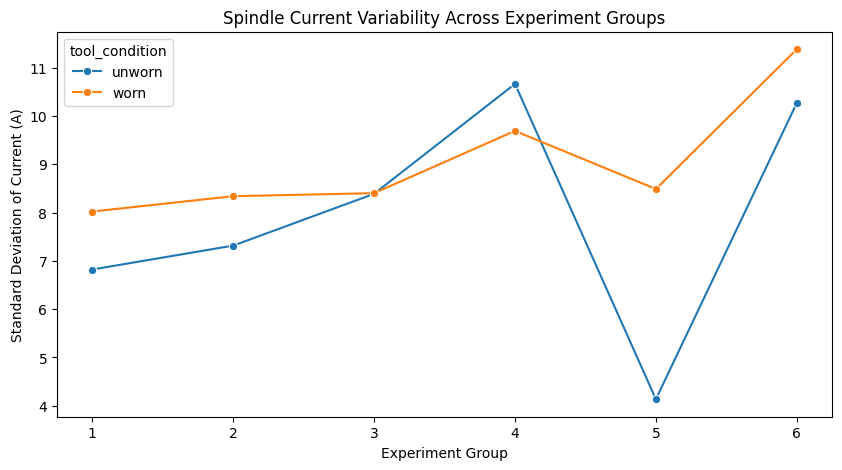

In [9]:
# Create a line plot graph showing how the variability (Standard deviation) of spindle current varies across experimental groups.
plt.figure(figsize=(10,5))

sns.lineplot(
    data=global_feature_df,
    x="group",
    y="std_current",
    hue="tool_condition",
    marker="o"
)

plt.title("Spindle Current Variability Across Experiment Groups")
plt.ylabel("Standard Deviation of Current (A)")
plt.xlabel("Experiment Group")

plt.show()

In [10]:
# --- STATISTICAL TESTS ---
# Compare mean and std of current between unworn and worn tool conditions
# using Welch's t-test (means) and Levene's test (variance) per group-process pair

results = []

# Get unique combinations of Group and Process
group_process_combos = window_df[["group", "process"]].drop_duplicates().values

for (g, p) in group_process_combos:
    # Filter for the specific group AND process
    gdf = window_df[(window_df["group"] == g) & (window_df["process"] == p)]

    unworn_mean = gdf[gdf["tool_condition"]=="unworn"]["mean_current"]
    worn_mean = gdf[gdf["tool_condition"]=="worn"]["mean_current"]

    unworn_std = gdf[gdf["tool_condition"]=="unworn"]["std_current"]
    worn_std = gdf[gdf["tool_condition"]=="worn"]["std_current"]

    # We only run the test if we have enough windows (at least 2) for both conditions
    if len(unworn_mean) > 1 and len(worn_mean) > 1:
        t_stat, t_p = ttest_ind(unworn_mean, worn_mean, equal_var=False)          # Welch's t-test: detects mean shift
        lev_stat, lev_p = levene(unworn_std, worn_std)                            # Levene's test: detects variance shift

        results.append({
            "Group": g,
            "Process": p,
            "Welch_pvalue": t_p,
            "Levene_pvalue": lev_p
        })

results_df = pd.DataFrame(results)

display(results_df)

,Group,Process,Welch_pvalue,Levene_pvalue
0,1,Layer 1 Down,0.333948,5.563001e-01
1,1,Layer 1 Up,0.616174,2.269714e-01
2,1,Layer 2 Down,0.565410,1.557413e-01
3,1,Layer 2 Up,0.333848,8.356962e-01
4,1,Layer 3 Down,0.836369,7.085197e-01
5,1,Layer 3 Up,0.674562,2.143907e-01
6,2,Layer 1 Down,0.145065,9.004509e-01
7,2,Layer 1 Up,0.258456,1.147560e-01
8,2,Layer 2 Down,0.112928,7.307897e-01
9,2,Layer 2 Up,0.008899,7.130303e-02


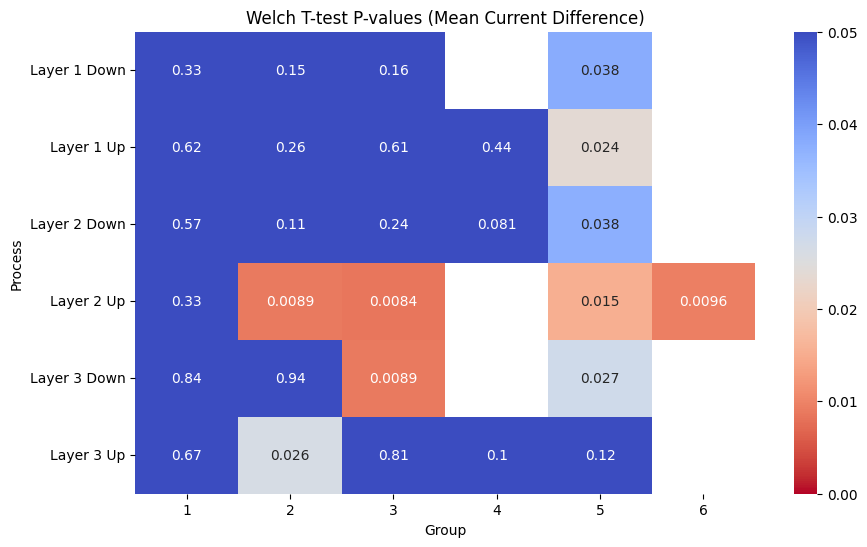

In [11]:
# Heatmap of Welch's t-test p-values across Process vs Group combinations
pivot_t = results_df.pivot(index="Process", columns="Group", values="Welch_pvalue")

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_t,
    annot=True,
    cmap="coolwarm_r",
    vmin=0,
    vmax=0.05
)

plt.title("Welch T-test P-values (Mean Current Difference)")
plt.show()

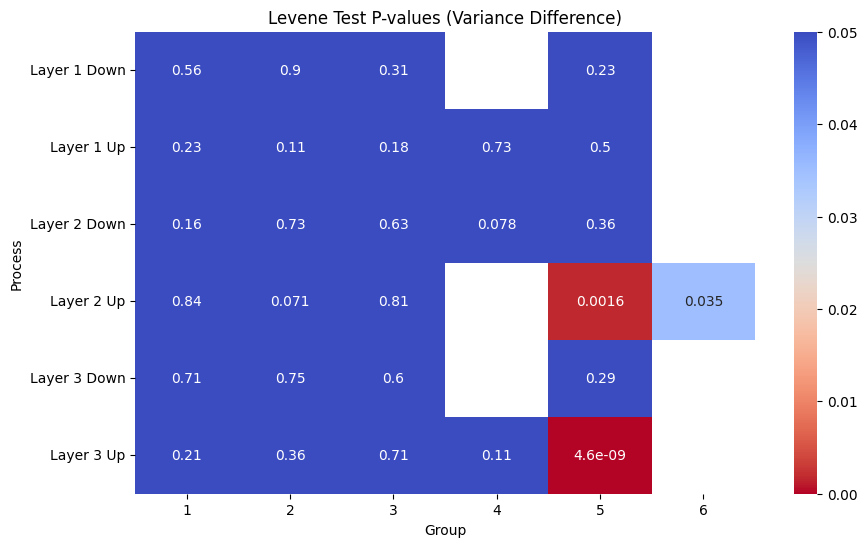

In [12]:
# Heatmap of Levene test p-values across Process vs Group combinations
pivot_l = results_df.pivot(index="Process", columns="Group", values="Levene_pvalue")

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_l,
    annot=True,
    cmap="coolwarm_r",
    vmin=0,
    vmax=0.05
)

plt.title("Levene Test P-values (Variance Difference)")
plt.show()

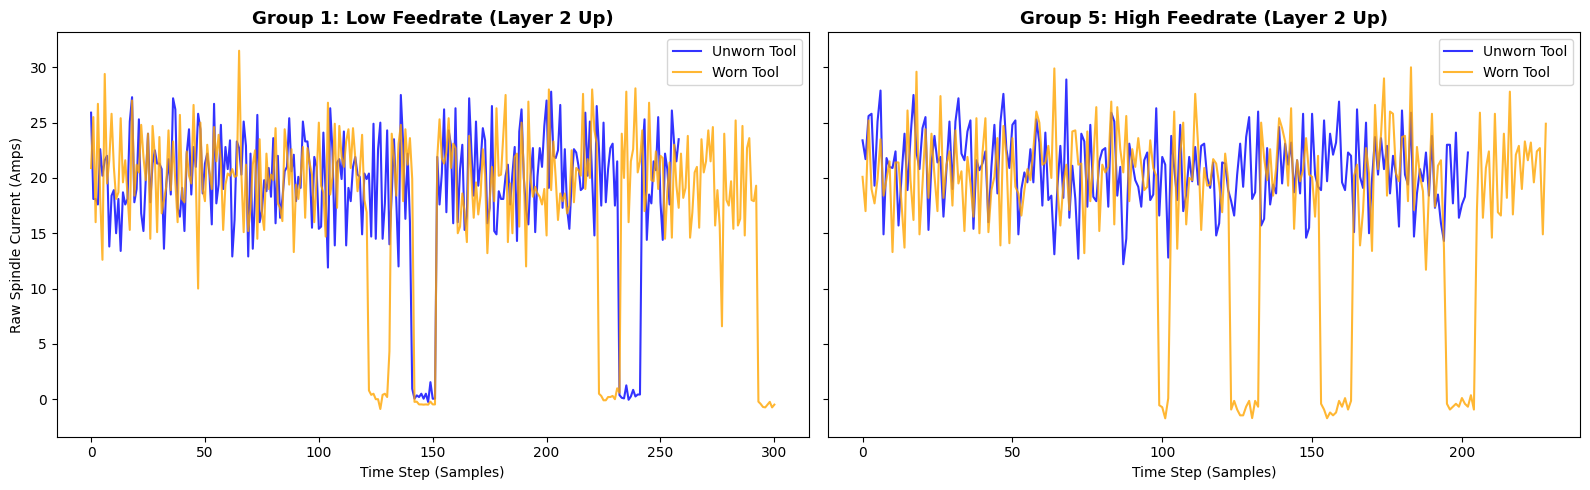

In [13]:
# Visual validation using time-series signal
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), sharey=True)


target_process = "Layer 2 Up"

# Plot 1: Group 1 Time-Series (Low Feedrate)
g1_unworn = df[(df["group"] == 1) & (df["Machining_Process"] == target_process) & (df["tool_condition"] == "unworn")]["S1_CurrentFeedback"].iloc[:500].values
g1_worn = df[(df["group"] == 1) & (df["Machining_Process"] == target_process) & (df["tool_condition"] == "worn")]["S1_CurrentFeedback"].iloc[:500].values

axes[0].plot(g1_unworn, label="Unworn Tool", alpha=0.8, color="blue")
axes[0].plot(g1_worn, label="Worn Tool", alpha=0.8, color="orange")
axes[0].set_title("Group 1: Low Feedrate (Layer 2 Up)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Time Step (Samples)")
axes[0].set_ylabel("Raw Spindle Current (Amps)")
axes[0].legend()


# Plot 2: Group 5 Time-Series (High Feedrate)
g5_unworn = df[(df["group"] == 5) & (df["Machining_Process"] == target_process) & (df["tool_condition"] == "unworn")]["S1_CurrentFeedback"].iloc[:500].values
g5_worn = df[(df["group"] == 5) & (df["Machining_Process"] == target_process) & (df["tool_condition"] == "worn")]["S1_CurrentFeedback"].iloc[:500].values

axes[1].plot(g5_unworn, label="Unworn Tool", alpha=0.8, color="blue")
axes[1].plot(g5_worn, label="Worn Tool", alpha=0.8, color="orange")
axes[1].set_title("Group 5: High Feedrate (Layer 2 Up)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Time Step (Samples)")
axes[1].legend()

# Clean up the layout and display
plt.tight_layout()
plt.show()

**Analysis: Research Question 2**

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [7]:
# Defining the parameters
window_size = 50
step_size = 25

# Convert a raw time-series signal into overlapping windows and extract summary features for each window
def extract_window_features(signal):

    segments = []

    for i in range(0, len(signal) - window_size + 1, step_size):

        window = signal[i:i+window_size]

        segments.append({
            "group": group,
            "mean_current": np.mean(window),
            "std_current": np.std(window),
            "rms_current": np.sqrt(np.mean(window**2)),
            "max_current": np.max(window),
            "min_current": np.min(window)
        })

    return segments

In [8]:
group_datasets = {}

for group in df["group"].unique():

    gdf = df[df["group"] == group]

    train_segments = []
    test_segments = []
    labels = []

    for process in gdf["Machining_Process"].unique():

        pdf = gdf[gdf["Machining_Process"] == process]

        # UNWORN
        unworn_signal = pdf[pdf["tool_condition"]=="unworn"]["S1_CurrentFeedback"].values

        split_index = int(len(unworn_signal) * 0.7)

        train_signal = unworn_signal[:split_index]
        test_signal = unworn_signal[split_index:]

        train_windows = extract_window_features(train_signal)
        test_windows_normal = extract_window_features(test_signal)

        train_segments += train_windows
        test_segments += test_windows_normal
        labels += [0]*len(test_windows_normal)

        # WORN
        worn_signal = pdf[pdf["tool_condition"]=="worn"]["S1_CurrentFeedback"].values

        worn_windows = extract_window_features(worn_signal)

        test_segments += worn_windows
        labels += [1]*len(worn_windows)

    train_df = pd.DataFrame(train_segments)
    test_df = pd.DataFrame(test_segments)

    group_datasets[group] = (train_df, test_df, np.array(labels))

In [9]:
# Feature set used for model training and evaluation
features = ["mean_current","std_current","rms_current","max_current","min_current"]

In [10]:
results = []

# Define models in one place
models = {
    "IsolationForest": IsolationForest(contamination=0.1, random_state=42),
    "OneClassSVM": OneClassSVM(nu=0.1),
    "LocalOutlierFactor": LocalOutlierFactor(n_neighbors=20, novelty=True)
}

for group, (train_df, test_df, y_test) in group_datasets.items():

    # Data Preparation
    X_train = train_df[features]
    X_test = test_df[features]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Model Loop
    for model_name, model in models.items():

        # Train model
        model.fit(X_train)

        # Predict anomalies
        preds = model.predict(X_test)
        preds = (preds == -1).astype(int)

        # Store results
        results.append({
            "Group": group,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1": f1_score(y_test, preds, zero_division=0)
        })

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:282: UserWarning: n_neighbors (20) is greater than the total number of samples (18). n_neighbors will be set to (n_samples - 1) for estimation.
  warnings.warn(


In [11]:
results_df = pd.DataFrame(results)
results_df

,Group,Model,Accuracy,Precision,Recall,F1
0,1,IsolationForest,0.181818,1.000000,0.068966,0.129032
1,1,OneClassSVM,0.484848,0.928571,0.448276,0.604651
2,1,LocalOutlierFactor,0.166667,1.000000,0.051724,0.098361
3,2,IsolationForest,0.178082,1.000000,0.062500,0.117647
4,2,OneClassSVM,0.260274,0.916667,0.171875,0.289474
5,2,LocalOutlierFactor,0.150685,1.000000,0.031250,0.060606
6,3,IsolationForest,0.190476,1.000000,0.037736,0.072727
7,3,OneClassSVM,0.190476,0.666667,0.075472,0.135593
8,3,LocalOutlierFactor,0.634921,0.894737,0.641509,0.747253
9,4,IsolationForest,0.280000,1.000000,0.142857,0.250000


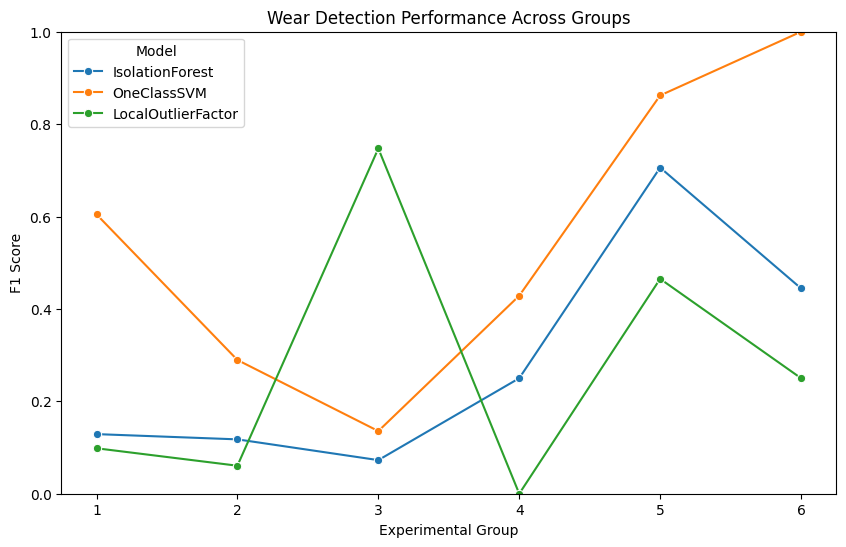

In [12]:
# Line plot comparing F1 scores across experimental groups for each model
plt.figure(figsize=(10,6))

sns.lineplot(
    data=results_df,
    x="Group",
    y="F1",
    hue="Model",
    marker="o"
)

plt.title("Wear Detection Performance Across Groups")
plt.ylabel("F1 Score")
plt.xlabel("Experimental Group")

plt.ylim(0,1)

plt.show()

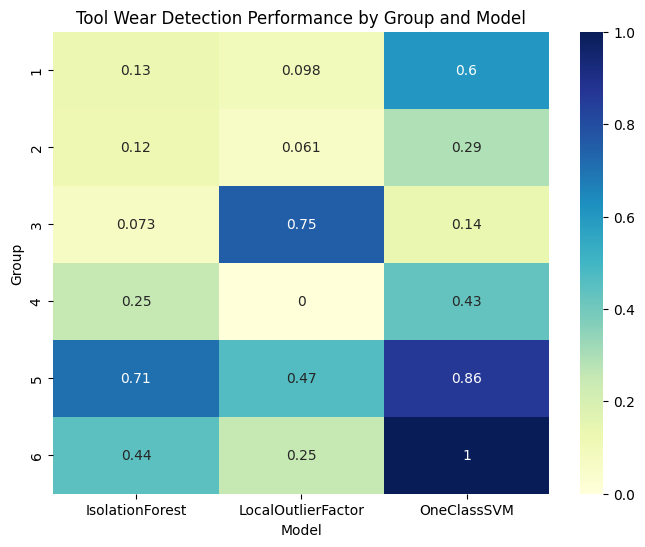

In [13]:
# Heatmap of F1 scores per Group-Model combination
pivot = results_df.pivot(index="Group", columns="Model", values="F1")

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title("Tool Wear Detection Performance by Group and Model")

plt.show()

In [14]:
# Train each anomaly detection model per group and collect anomaly score
score_records = []

# Define models
models = {
    "IsolationForest": IsolationForest(contamination=0.1, random_state=42),
    "OneClassSVM": OneClassSVM(nu=0.1),
    "LocalOutlierFactor": LocalOutlierFactor(n_neighbors=20, novelty=True)
}

for group, (train_df, test_df, y_test) in group_datasets.items():

    # Data Preparation
    X_train = train_df[features]
    X_test = test_df[features]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Model Loop
    for model_name, model in models.items():

        # Train model
        model.fit(X_train)

        # Get anomaly scores
        scores = model.decision_function(X_test)

        # Store results
        for s, label in zip(scores, y_test):
            score_records.append({
                "group": group,
                "model": model_name,
                "anomaly_score": s,
                "tool_condition": "worn" if label == 1 else "unworn"
            })

# Final dataframe
score_df = pd.DataFrame(score_records)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:282: UserWarning: n_neighbors (20) is greater than the total number of samples (18). n_neighbors will be set to (n_samples - 1) for estimation.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


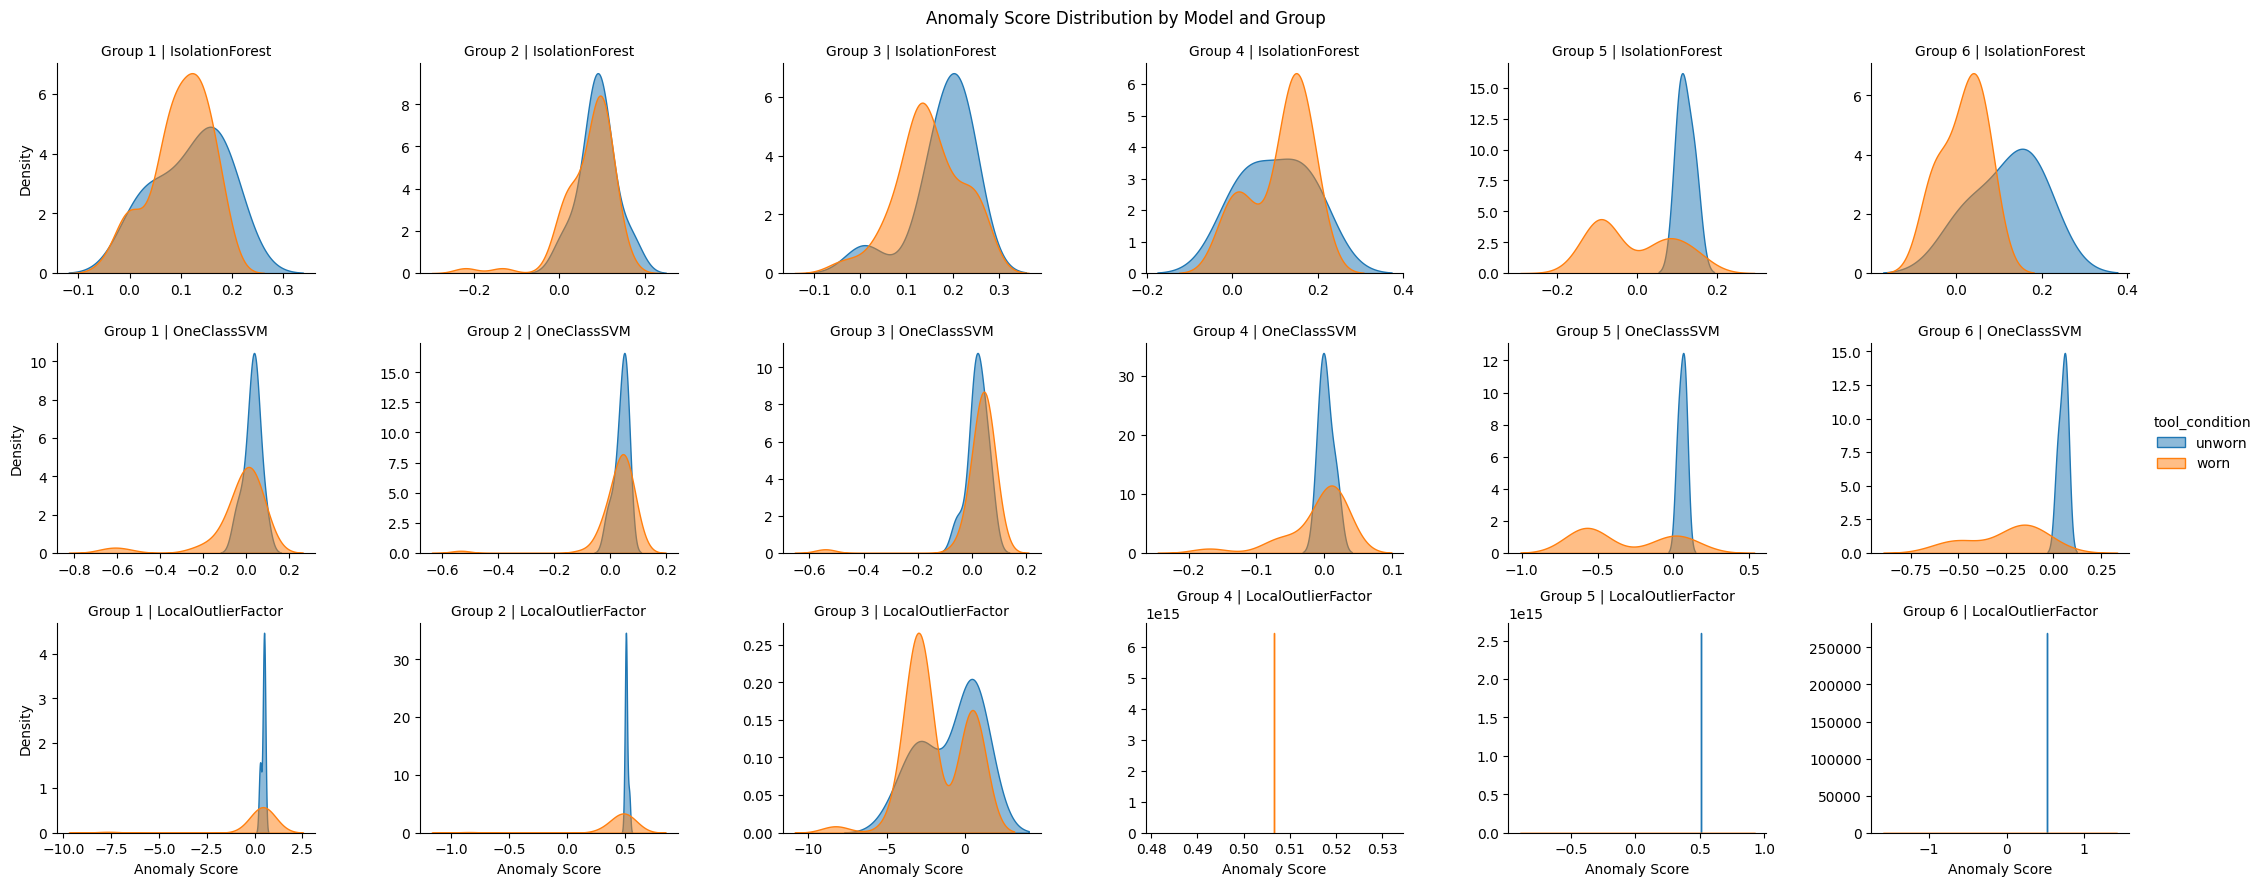

In [15]:
# KDE plot grid showing anomaly score distributions for worn vs unworn windows per group in each model
g = sns.FacetGrid(
    score_df,
    row="model",
    col="group",
    hue="tool_condition",
    height=3,
    aspect=1.2,
    sharex=False,
    sharey=False
)

g.map(sns.kdeplot, "anomaly_score", fill=True, alpha=0.5)
g.add_legend()

g.set_titles("Group {col_name} | {row_name}")
g.set_axis_labels("Anomaly Score", "Density")

plt.subplots_adjust(top=0.92)
g.fig.suptitle("Anomaly Score Distribution by Model and Group")

plt.show()

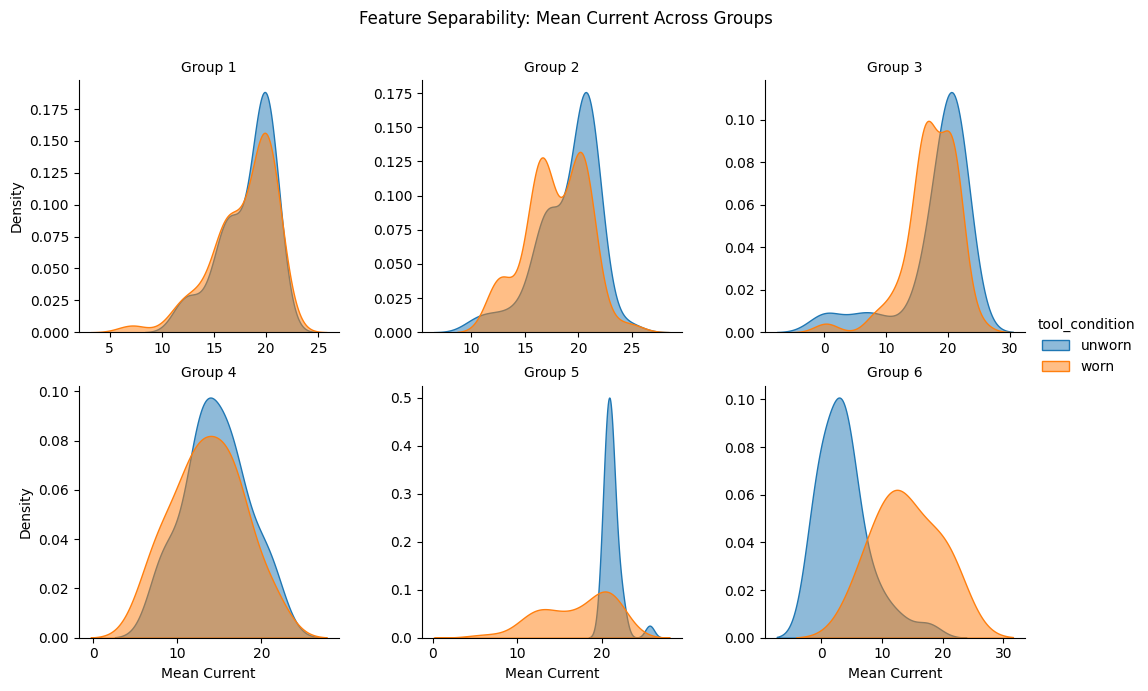

In [19]:
# KDE plot showing mean current distributions for worn vs unworn windows per group
g = sns.FacetGrid(
    window_df,
    col="group",
    hue="tool_condition",
    col_wrap=3,
    height=3.5,
    sharex=False,
    sharey=False
)

g.map(sns.kdeplot, "mean_current", fill=True, alpha=0.5)

g.add_legend()
g.set_titles("Group {col_name}")
g.set_axis_labels("Mean Current", "Density")

plt.subplots_adjust(top=0.88)
g.fig.suptitle("Feature Separability: Mean Current Across Groups")

plt.show()

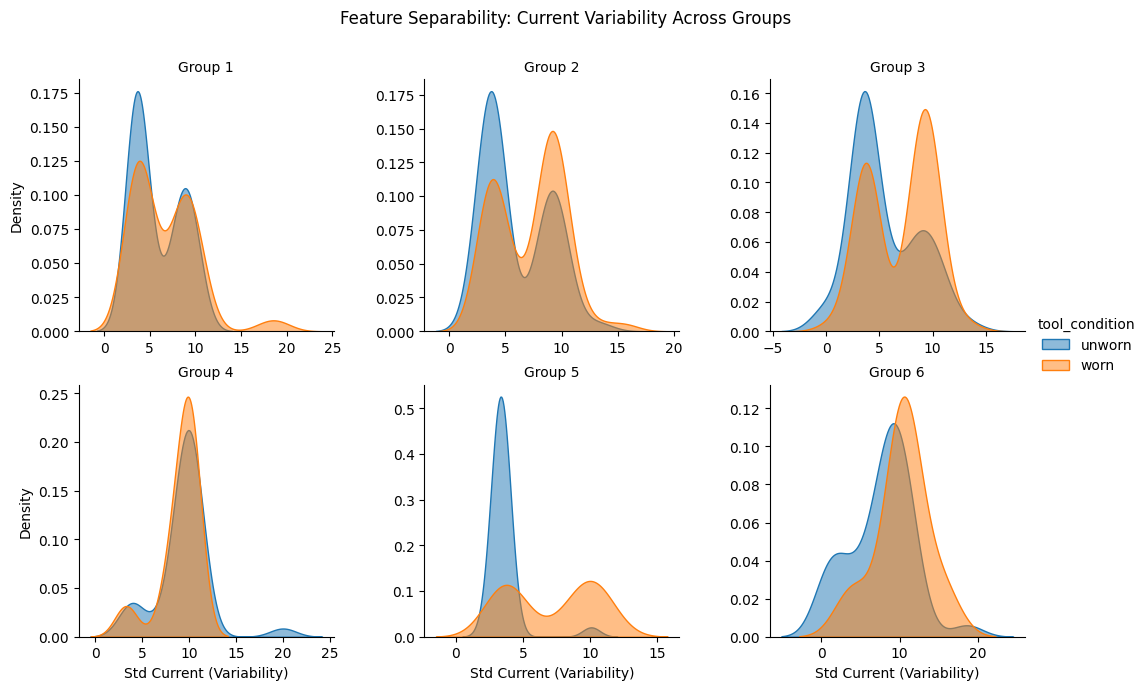

In [20]:
# KDE plot showing std current distributions for worn vs unworn windows per group
g = sns.FacetGrid(
    window_df,
    col="group",
    hue="tool_condition",
    col_wrap=3,
    height=3.5,
    sharex=False,
    sharey=False
)

g.map(sns.kdeplot, "std_current", fill=True, alpha=0.5)

g.add_legend()
g.set_titles("Group {col_name}")
g.set_axis_labels("Std Current (Variability)", "Density")

plt.subplots_adjust(top=0.88)
g.fig.suptitle("Feature Separability: Current Variability Across Groups")

plt.show()

In [21]:
# Quantify feature separability per group and correlate with model F1 scores,
# testing whether groups with more distinct worn/unworn distributions are easier to detect
separability = []

for group in window_df["group"].unique():

    gdf = window_df[window_df["group"] == group]

    unworn = gdf[gdf["tool_condition"]=="unworn"]
    worn = gdf[gdf["tool_condition"]=="worn"]

    sep_mean = abs(unworn["mean_current"].mean() - worn["mean_current"].mean())
    sep_std = abs(unworn["std_current"].mean() - worn["std_current"].mean())

    separability.append({
        "Group": group,
        "Mean_Separation": sep_mean,
        "Std_Separation": sep_std
    })

sep_df = pd.DataFrame(separability)

In [22]:
# Average F1 across all models per group for a single performance score per group
f1_scores = results_df.groupby("Group")["F1"].mean().reset_index()

# Merge separability and F1 to analyse whether feature separability predicts model performance
analysis_df = pd.merge(sep_df, f1_scores, on="Group")
analysis_df

,Group,Mean_Separation,Std_Separation,F1
0,1,0.375794,0.864019,0.277348
1,2,1.149426,1.288232,0.155909
2,3,0.764307,1.570304,0.318524
3,4,0.962831,0.409800,0.226190
4,5,4.082559,3.547021,0.677689
5,6,10.304274,2.655363,0.564815


In [23]:
# Pearson correlation: how strongly does feature separability predict F1 score?
print("Correlation (Mean):", analysis_df["Mean_Separation"].corr(analysis_df["F1"]))
print("Correlation (Std):", analysis_df["Std_Separation"].corr(analysis_df["F1"]))

Correlation (Mean): 0.7107137976834559
Correlation (Std): 0.9251079676100571
